In [1]:
import sys
sys.path.insert(0, '../../')

from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock
from panel_exp.design.design_metrics import imbalance
import copy

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import RidgeCV, Ridge
from panel_exp.methods.scm import SyntheticControl, AugSynth 

from panel_exp.inference import conformal
import pandas as pd
import numpy as np
from panel_exp.impact import ImpactAnalyzer
from panel_exp.inference.unit_jackknife import unit_jk, unit_jackknife
from panel_exp.inference.conformal import conformal

from scipy.optimize import minimize
from sklearn.linear_model import RidgeCV, Ridge
import warnings
from panel_exp.methods.tbr import TBR, TBRRidge
import cvxpy as cp
  
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
from panel_exp.design import power

import multiprocessing

proc = multiprocessing.cpu_count()

In [2]:
data = pd.read_csv('../../examples/data/google_sales.csv')

In [3]:
wide_df = pd.pivot_table(data, index='geo', columns='date', values='sales', fill_value=0)

test = data[data.group==2].geo.unique()
control = data[data.group==1].geo.unique()

control_units = pd.DataFrame(wide_df.loc[control]).T
treated_units = pd.DataFrame(wide_df.loc[test].sum(axis=0), columns=['treated'])

wide_agg = pd.concat([treated_units, control_units], axis=1)

In [4]:
test=['treated']

pds = PanelDataset(wide_agg.T
                ,  treated_periods = [TimePeriod(start="2015-02-16", end="2015-03-15") for _ in range(len(test))]
                ,  treated_units = list(test))

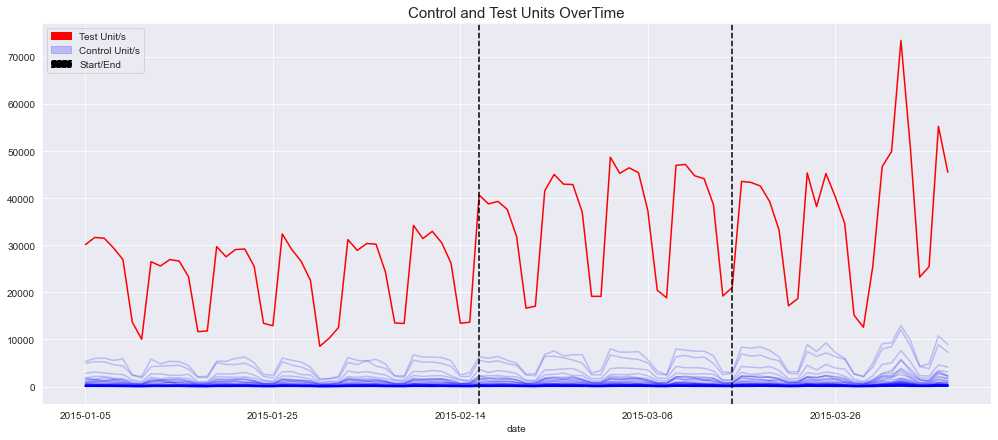

In [5]:
pds.plot()

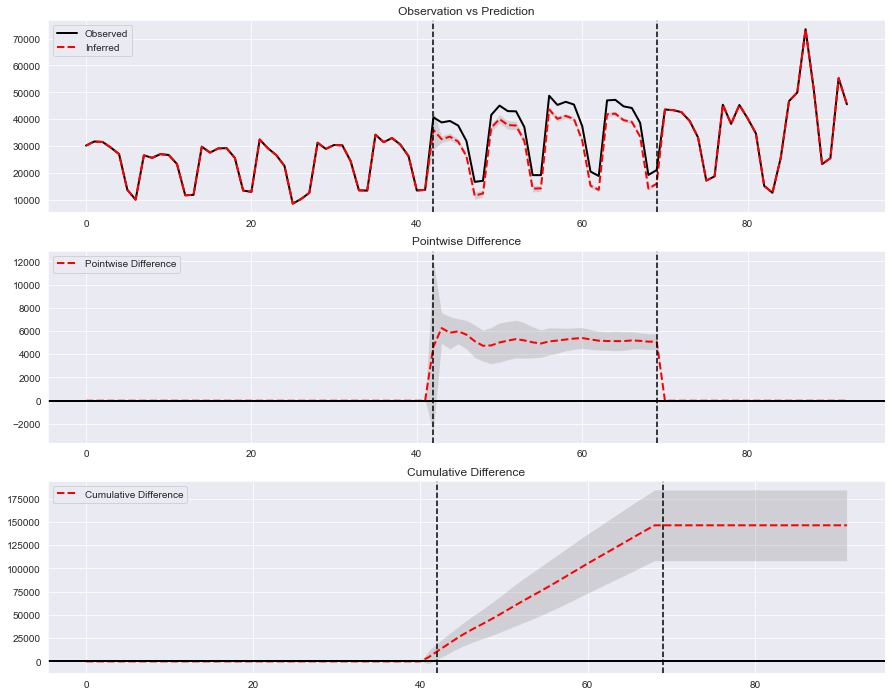

In [6]:
est = TBRRidge( inference='Kfold')
est.run_analysis(pds)

est.plot()

In [7]:
wide_df = pd.pivot_table(data, index='geo', columns='date', values='sales', fill_value=0)

test = data[data.group==2].geo.unique()
control = data[data.group==1].geo.unique()

control_units = pd.DataFrame(wide_df.loc[control]).T
treated_units = pd.DataFrame(wide_df.loc[test]).T 

wide_agg = pd.concat([treated_units, control_units], axis=1)

In [8]:
print("We can remove all data after %s as this is simulating a pre-test analysis" % pds.test_start)

We can remove all data after 2015-02-16 as this is simulating a pre-test analysis


In [9]:
wide_agg_pre = wide_agg[wide_agg.index<pds.test_start]

In [10]:
wide_agg_pre

# pds = PanelDataset(wide_agg.T, treated_units = ['treated'], treated_periods=[TimePeriod(start=L-test_length)])
L = wide_agg_pre.shape[0]
test_length = 14 

pds = PanelDataset(wide_agg_pre.T
                ,  treated_periods = [TimePeriod(start=wide_agg_pre.T.columns[L-test_length]) for _ in range(len(test))]
                ,  treated_units = list(test))

In [11]:
pa = power.PowerAnalysis(pds
                         , TBRRidge
                         , 'Kfold'
                         , test_length 
                         , mx_effect=.25 
                         , n_jobs=1)

In [12]:
pa.run_analysis()

  0%|          | 0/42 [00:00<?, ?it/s]

100%|██████████| 42/42 [05:07<00:00,  7.32s/it]


In [14]:
#pa.plot_power_curve()
# this returns an expected error as no MDE is found 

In [ ]:
pa.summary()

,Parameters
Model,TBRRidge
Inference,Kfold
Test Length,14
Number of Simulations,2058
,Statistics
MDE Percent,0.25
MDE KPI,82486.565833
Power,0.8
Type 1 Error Rate,0.0
